In [1]:
from echopop import Survey
from echopop.extensions import generate_reports

from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Set paths
survey_year = 2021
path_init = f"/Users/wujung/code_git/echopop/config_files/initialization_config_{survey_year}.yml"
path_config = f"/Users/wujung/code_git/echopop/config_files/survey_year_{survey_year}_config.yml"

report_path = "/Users/wujung/code_git/echopop/202502_echopop_test/reports"

In [6]:
# Inititate Survey object
survey = Survey(init_config_path=path_init, survey_year_config_path=path_config)

In [7]:
# Load acoustic data (Echoview export ingestion)
survey.load_acoustic_data(
    ingest_exports="echoview",
    transect_pattern="T(\\d+)",
    read_transect_region_file=False,
    write_transect_region_file=False
)

Updated NASC export file for group 'all_ages' saved at '/Users/wujung/code_git/echopop/202502_echopop_test/data_from_RT/2021/Exports/US_CAN_NASC_2021_table_all_ages.xlsx'.
Updated NASC export file for group 'no_age1' saved at '/Users/wujung/code_git/echopop/202502_echopop_test/data_from_RT/2021/Exports/US_CAN_NASC_2021_table_no_age1.xlsx'.


In [8]:
# Load acoustic data (Already-defined file)
survey =  Survey(path_init, path_config)
survey.load_acoustic_data()

In [9]:
pprint(survey.meta)

{'provenance': {'date': '2025-03-05 21:50:32', 'imported_datasets': {'NASC'}}}


In [10]:
pprint(survey.config)

{'CAN_haul_offset': 200,
 'NASC': {'all_ages': {'filename': 'Exports/US_CAN_NASC_2021_table_all_ages.xlsx',
                       'sheetname': 'Sheet1'},
          'no_age1': {'filename': 'Exports/US_CAN_NASC_2021_table_no_age1.xlsx',
                      'sheetname': 'Sheet1'}},
 'TS_length_regression_parameters': {'pacific_hake': {'TS_L_intercept': -68.0,
                                                      'TS_L_slope': 20.0,
                                                      'length_units': 'cm',
                                                      'number_code': 22500}},
 'biological': {'catch': {'CAN': {'filename': 'Biological/CAN/biodata_catch_2021_CAN.xlsx',
                                  'sheetname': 'Sheet1'},
                          'US': {'filename': 'Biological/US/biodata_catch_2021_US.xlsx',
                                 'sheetname': 'Sheet1'}},
                'length': {'CAN': {'filename': 'Biological/CAN/biodata_length_2021_CAN.xlsx',
                   

In [11]:
# Load survey data
survey.load_survey_data()

/Users/wujung/miniconda3/envs/echopop_20250228/lib/python3.9/site-packages/echopop/utils/validate_df.py:69: UserWarning: The following row indices from /Users/wujung/code_git/echopop/202502_echopop_test/data_from_RT/2021/Biological/CAN/biodata_catch_2021_CAN.xlsx contained invalid values and were dropped from the validated DataFrame: [0, 3, 4, 10, 11, 12, 13, 18, 29, 30, 37, 40, 53, 88, 105, 114, 118, 124, 152, 159, 162, 164, 165, 169]
  warnings.warn(


In [ ]:
# Transect analysis test: KS strata
survey.transect_analysis(
    exclude_age1=True,
    stratum="ks",  # or "inpfc"
    verbose=True
)

--------------------------------
TRANSECT RESULTS
--------------------------------
| Variable: Biomass (kmt)
| Age-1 fish excluded: True
| Stratum definition: KS
--------------------------------
GENERAL RESULTS
--------------------------------
| Total biomass: 1459.5 kmt
    Age-1: 161.9 kmt
    Age-2+: 1297.6 kmt
| Total female biomass: 443.6 kmt
    Age-1: 82.9 kmt
    Age-2+: 360.7 kmt
| Total male biomass: 479.2 kmt
    Age-1: 79.0 kmt
    Age-2+: 400.2 kmt
| Total unsexed biomass: 536.7 kmt
| Total mixed biomass: 0.0 kmt
--------------------------------


In [16]:
# Kriging with extrapolation
survey.kriging_analysis(
    extrapolate=True,
    best_fit_variogram=False,
    verbose=False
)

In [21]:
survey.generate_reports(
    save_directory=report_path
)

The following report tables were generated:
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/aged_len_haul_counts_table.xlsx'
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/EchoPro_kriged_aged_output_0.xlsx'
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/EchoPro_kriged_aged_output_1.xlsx'
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/EchoPro_kriged_output_0.xlsx'
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/EchoPro_kriged_output_1.xlsx'
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/kriged_len_age_abundance_table.xlsx'
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/kriged_len_age_biomass_table.xlsx'
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/kriging_input.xlsx'
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/total_len_haul_counts_table.xlsx'
   -'/Users/wujung/code_git/echopop/202502_echopop_test/reports/EchoPro_un-kriged_aged_outp

In [22]:
survey.summary("kriging")

--------------------------------
KRIGING RESULTS (MESH)
--------------------------------
| Kriged variable: Biomass (kg/nmi^2)
| Age-1 fish excluded: True
| Stratum definition: KS
| Mesh extrapolation: True
    Extrapolated over uncropped grid
| Mesh and transect coordinate standardization: True
--------------------------------
GENERAL RESULTS
--------------------------------
| Mean biomass: 11624.54 kg/nmi^2
| Total survey biomass estimate: 1434.92 kmt
| Mean mesh sample CV: 0.11
| Overall survey CV: 0.1217
| Total area coverage: 118187.6 nmi^2
--------------------------------


In [26]:
survey.summary("transect")

--------------------------------
TRANSECT RESULTS
--------------------------------
| Variable: Biomass (kmt)
| Age-1 fish excluded: True
| Stratum definition: KS
--------------------------------
GENERAL RESULTS
--------------------------------
| Total biomass: 1459.5 kmt
    Age-1: 161.9 kmt
    Age-2+: 1297.6 kmt
| Total female biomass: 443.6 kmt
    Age-1: 82.9 kmt
    Age-2+: 360.7 kmt
| Total male biomass: 479.2 kmt
    Age-1: 79.0 kmt
    Age-2+: 400.2 kmt
| Total unsexed biomass: 536.7 kmt
| Total mixed biomass: 0.0 kmt
--------------------------------


In [27]:
survey.summary("kriging")

--------------------------------
KRIGING RESULTS (MESH)
--------------------------------
| Kriged variable: Biomass (kg/nmi^2)
| Age-1 fish excluded: True
| Stratum definition: KS
| Mesh extrapolation: True
    Extrapolated over uncropped grid
| Mesh and transect coordinate standardization: True
--------------------------------
GENERAL RESULTS
--------------------------------
| Mean biomass: 11624.54 kg/nmi^2
| Total survey biomass estimate: 1434.92 kmt
| Mean mesh sample CV: 0.11
| Overall survey CV: 0.1217
| Total area coverage: 118187.6 nmi^2
--------------------------------


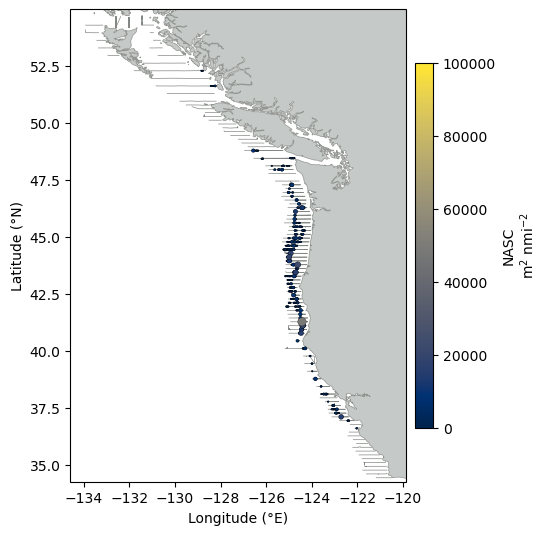

In [29]:
survey.plot(kind="transect", variable="nasc")

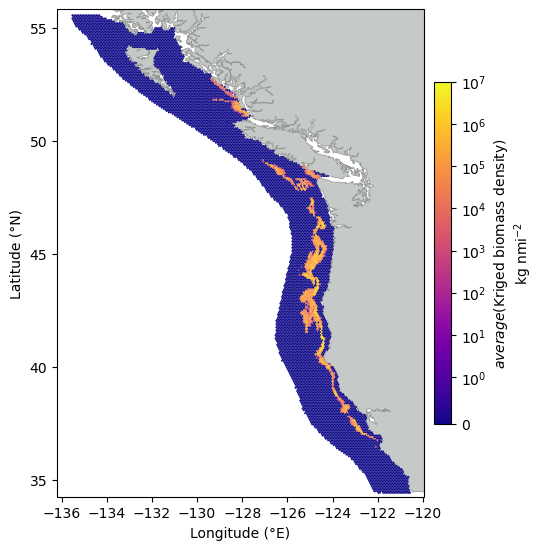

In [30]:
survey.plot(
    kind="mesh", 
    variable="biomass_density", 
    plot_type="hexbin", 
    plot_parameters={
        "reduce_C_function": np.sum, 
        "colorbar_label": "$average$(Kriged biomass density)\nkg nmi$^{-2}$",
        "log_base": 10
    }
)

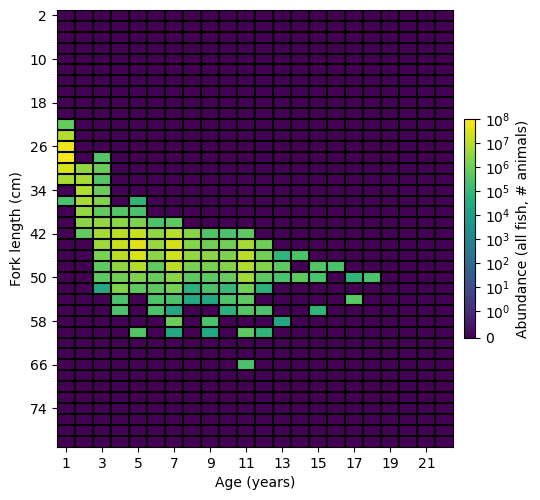

In [31]:
survey.plot(
    kind="age_length_distribution", 
    variable="abundance", 
    plot_parameters={"log_base": 10}
)